In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
torch.cuda.get_device_name(0)

'Tesla T4'

In [3]:
device = torch.device("cuda" if torch.cuda.is_available else "cpu")
print(device)

cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
X_train_loaded = pd.read_csv("/content/drive/MyDrive/flight_price_predictions/train_data_to_colab.csv")
X_test_loaded = pd.read_csv("/content/drive/MyDrive/flight_price_predictions/test_data_to_colab.csv")

In [6]:
X_train_loaded.head(5)

,number_of_changes,duration,distance,departure_year,days_to_departure,is_weekend,month_part_middle,month_part_start,departure_month_2,departure_month_3,...,destination_LON,destination_MOW,destination_PAR,destination_SHJ,destination_TBS,destination_TYO,season_Spring,season_Summer,season_Winter,value
0,1,0.556224,-0.325961,0,0.658114,0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,57314
1,2,0.726404,1.661041,0,0.061892,1,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,40005
2,2,1.276217,1.492267,0,-0.908430,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,33338
3,0,-1.276486,-1.174129,0,0.003439,0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3390
4,0,-1.008125,-0.712735,1,1.418005,0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,13806


In [7]:
y_train = X_train_loaded["value"]
y_test = X_test_loaded["value"]
X_train_loaded.drop(columns="value", axis=1, inplace=True)
X_test_loaded.drop(columns="value", axis=1, inplace=True)


In [8]:
from torch.utils.data import TensorDataset, DataLoader
X_tensor = torch.tensor(X_train_loaded.values, dtype=torch.float32)
y_tensor = torch.tensor(y_train.values, dtype=torch.float32)
train_dataset = TensorDataset(X_tensor, y_tensor)
batch_size = 64
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=batch_size,
                          shuffle=True
                          )

X_test_tensor = torch.tensor(X_test_loaded.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [21]:
class ResidualBlock(nn.Module):
  def __init__(self, hidden_dim: int, dropout_rate: float):
    super().__init__()
    self.ln = nn.LayerNorm(hidden_dim)
    self.linear = nn.Linear(hidden_dim, hidden_dim)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(dropout_rate)

  def forward(self, x):
    identity = x
    out = self.ln(x)
    out = self.linear(out)
    out = self.relu(out)
    out = self.dropout(out)

    return out + identity

class Flight_price_predictor(nn.Module):
  def __init__(self, input_dim, hidden_dim: int=128, num_layers: int=20):
    super().__init__()
    self.input_layer = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.LayerNorm(hidden_dim),
        nn.ReLU(),
        nn.Dropout(0.2)
    )

    self.hidden_layers = nn.ModuleList([
        ResidualBlock(hidden_dim, dropout_rate=0.2) for _ in range(num_layers)
    ])

    self.final_norm = nn.LayerNorm(hidden_dim)
    self.output_layer = nn.Linear(hidden_dim, 1)

  def forward(self, x):
    x = self.input_layer(x)
    for layer in self.hidden_layers:
      x = layer(x)
    x = self.final_norm(x)
    x = self.output_layer(x)
    return x

In [22]:
model = Flight_price_predictor(input_dim=66).to(device)
criterion = nn.SmoothL1Loss()
optimizer = optim.AdamW(params=model.parameters(), lr=0.001)
epochs = 150

In [23]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
def evaluate_model(model, test_loader) -> tuple:
  model.eval()
  all_preds = []
  all_targets = []
  with torch.no_grad():
    for X_batch, y_batch in test_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)
      predictions = model(X_batch).squeeze()
      if predictions.ndim == 0:
        predictions = predictions.unsqueeze(0)
      all_preds.extend(predictions.cpu().numpy())
      all_targets.extend(y_batch.cpu().numpy())
  all_preds = np.array(all_preds)
  all_targets = np.array(all_targets)
  mae = mean_absolute_error(all_targets, all_preds)
  mape = mean_absolute_percentage_error(all_targets, all_preds)
  #print(f"MAE: {mae:.4f}")
  #print(f"MAPE: {(mape * 100):.2f}")
  return mae, mape


In [24]:
import matplotlib.pyplot as plt
history_train_loss = []
history_test_loss = []

for epoch in range(epochs):
  model.train()
  running_loss = 0.0
  for X_batch, y_batch in train_loader:
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)
    optimizer.zero_grad()
    preds = model(X_batch).squeeze()
    loss = criterion(preds, y_batch)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  avg_train_loss = running_loss / len(train_loader)
  val_loss, mape = evaluate_model(model, test_loader)
  history_train_loss.append(avg_train_loss)
  history_test_loss.append(val_loss)
  if (epoch + 1) % 10 == 0:
    print(f"Epoch: {epoch + 1}, TrainLoss: {avg_train_loss:.4f}")
print("Обучение завершено")

Epoch: 10, TrainLoss: 15903.1948
Epoch: 20, TrainLoss: 7595.3225
Epoch: 30, TrainLoss: 3441.4933
Epoch: 40, TrainLoss: 2678.9847
Epoch: 50, TrainLoss: 2438.0735
Epoch: 60, TrainLoss: 2332.9301
Epoch: 70, TrainLoss: 2253.9965
Epoch: 80, TrainLoss: 2168.6292
Epoch: 90, TrainLoss: 2122.7465
Epoch: 100, TrainLoss: 2084.4993
Epoch: 110, TrainLoss: 2072.3947
Epoch: 120, TrainLoss: 2083.9309
Epoch: 130, TrainLoss: 2018.1612
Epoch: 140, TrainLoss: 1997.2310
Epoch: 150, TrainLoss: 2007.7972
Обучение завершено


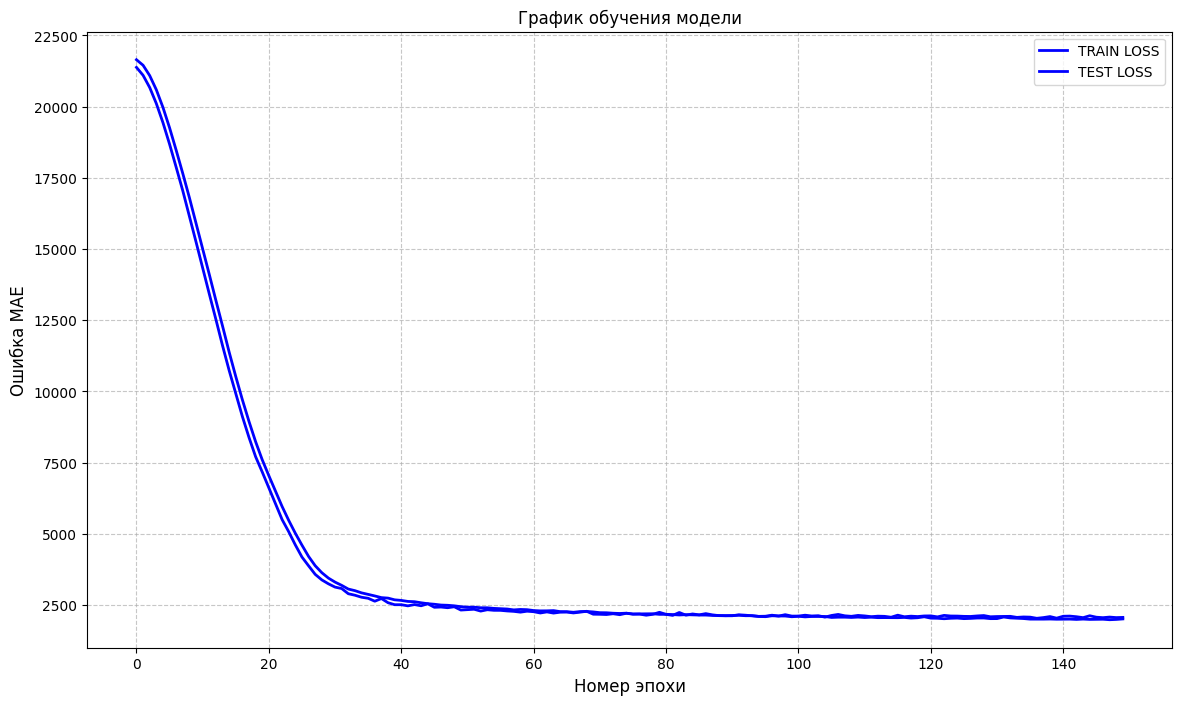

In [25]:
plt.figure(figsize=(14, 8))
plt.plot(history_train_loss, label="TRAIN LOSS", color="blue", linewidth=2)
plt.plot(history_test_loss, label="TEST LOSS", color="blue", linewidth=2)
plt.title("График обучения модели")
plt.xlabel("Номер эпохи", fontsize=12)
plt.ylabel("Ошибка MAE", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()


In [26]:
mae, mape = evaluate_model(model, test_loader)
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}")

MAE: 2061.7715
MAPE: 0.11
